# Reintegration Readiness Scorer
## HavenBridge ML Pipeline 2

### Problem Framing

**Business Question:** Which residents are ready for reintegration back into society, and what factors best predict successful reintegration completion?

Reintegration is the ultimate goal for every resident at HavenBridge — helping girls transition safely back to family, foster care, independent living, or adoption. Caseworkers currently rely on subjective judgment to determine readiness. A data-driven readiness score would help staff make more consistent, evidence-based decisions and ensure no girl is discharged before she is truly ready.

**Target Variable:** `reintegration_status` — Not Started, In Progress, On Hold, Completed

**Secondary Target:** `is_ready` — binary flag for residents whose reintegration is Completed or actively In Progress (vs On Hold or Not Started)

**Type:** Predictive (multi-class + binary classification)

**Success Metric:** Weighted F1-score, AUC-ROC, feature importance for caseworker guidance

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.multiclass import unique_labels
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load datasets — update path if needed
BASE = '/Users/emmafrederick/Downloads/lighthouse_csv_v7/'

residents_df = pd.read_csv(BASE + 'residents.csv')
health_df = pd.read_csv(BASE + 'health_wellbeing_records.csv')
education_df = pd.read_csv(BASE + 'education_records.csv')
plans_df = pd.read_csv(BASE + 'intervention_plans.csv')
visitations_df = pd.read_csv(BASE + 'home_visitations.csv')
recordings_df = pd.read_csv(BASE + 'process_recordings.csv')
incidents_df = pd.read_csv(BASE + 'incident_reports.csv')

print(f'Residents: {residents_df.shape}')
print(f'Health records: {health_df.shape}')
print(f'Education records: {education_df.shape}')
print(f'Intervention plans: {plans_df.shape}')
print(f'Home visitations: {visitations_df.shape}')
print()
print('Reintegration status distribution:')
print(residents_df['reintegration_status'].value_counts())

Residents: (60, 49)
Health records: (534, 14)
Education records: (534, 10)
Intervention plans: (180, 11)
Home visitations: (1337, 14)

Reintegration status distribution:
reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7
Name: count, dtype: int64


## Section 2: Exploratory Data Analysis

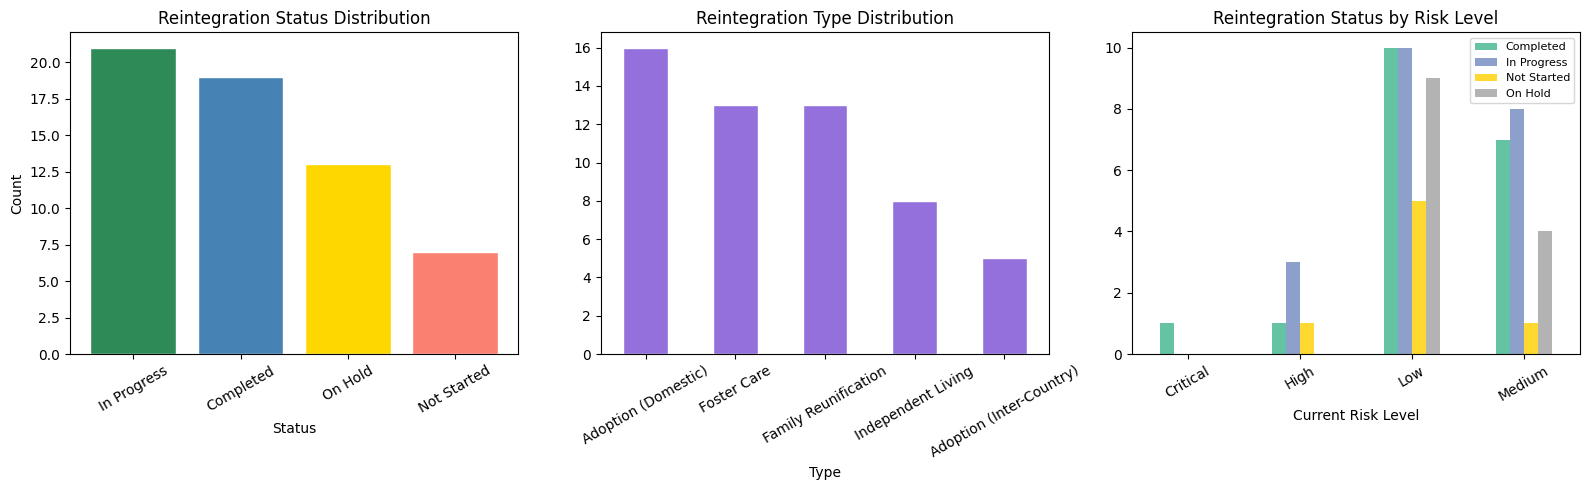

In [3]:
# Reintegration status and type distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

status_counts = residents_df['reintegration_status'].value_counts()
colors = ['seagreen', 'steelblue', 'gold', 'salmon']
axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Reintegration Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

type_counts = residents_df['reintegration_type'].value_counts()
type_counts.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Reintegration Type Distribution')
axes[1].set_xlabel('Type')
axes[1].tick_params(axis='x', rotation=30)

# Reintegration status by risk level
risk_reint = residents_df.groupby(['current_risk_level', 'reintegration_status']).size().unstack(fill_value=0)
risk_reint.plot(kind='bar', ax=axes[2], colormap='Set2')
axes[2].set_title('Reintegration Status by Risk Level')
axes[2].set_xlabel('Current Risk Level')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

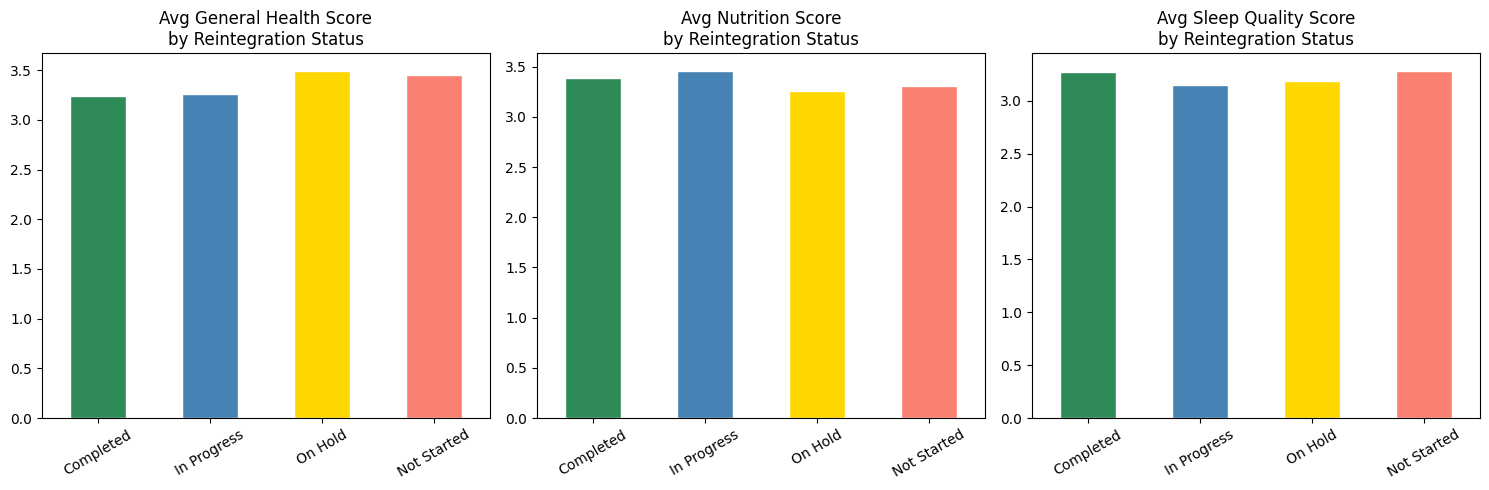

In [4]:
# Health scores by reintegration status
health_latest = health_df.sort_values('record_date').groupby('resident_id').last().reset_index()
health_reint = health_latest.merge(
    residents_df[['resident_id', 'reintegration_status']], on='resident_id'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
status_order = ['Completed', 'In Progress', 'On Hold', 'Not Started']

for ax, col in zip(axes, ['general_health_score', 'nutrition_score', 'sleep_quality_score']):
    health_reint.groupby('reintegration_status')[col].mean().reindex(status_order).plot(
        kind='bar', ax=ax, color=colors, edgecolor='white'
    )
    ax.set_title(f'Avg {col.replace("_", " ").title()}\nby Reintegration Status')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

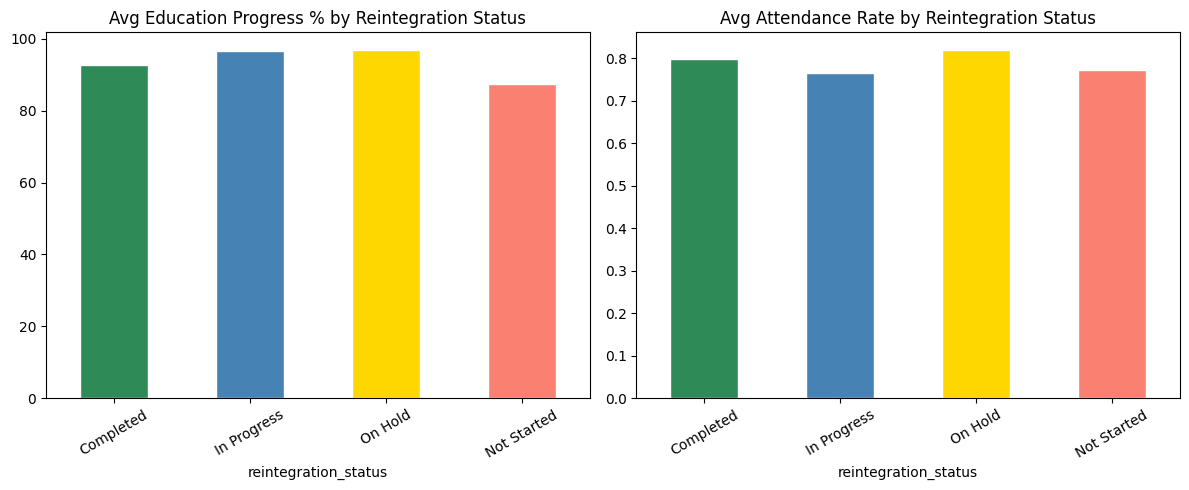

In [5]:
# Education progress by reintegration status
edu_latest = education_df.sort_values('record_date').groupby('resident_id').last().reset_index()
edu_reint = edu_latest.merge(
    residents_df[['resident_id', 'reintegration_status']], on='resident_id'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

edu_reint.groupby('reintegration_status')['progress_percent'].mean().reindex(status_order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Avg Education Progress % by Reintegration Status')
axes[0].tick_params(axis='x', rotation=30)

edu_reint.groupby('reintegration_status')['attendance_rate'].mean().reindex(status_order).plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white'
)
axes[1].set_title('Avg Attendance Rate by Reintegration Status')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [6]:
# Home visitation outcomes by reintegration status
visit_agg = visitations_df.groupby('resident_id').agg(
    total_visits=('visitation_id', 'count'),
    favorable_visits=('visit_outcome', lambda x: (x == 'Favorable').sum()),
    safety_concerns=('safety_concerns_noted', 'sum'),
    follow_ups_needed=('follow_up_needed', 'sum')
).reset_index()

visit_reint = visit_agg.merge(
    residents_df[['resident_id', 'reintegration_status']], on='resident_id'
)

print('=== HOME VISITATION OUTCOMES BY REINTEGRATION STATUS ===')
print(visit_reint.groupby('reintegration_status')[[
    'total_visits', 'favorable_visits', 'safety_concerns'
]].mean().round(2).reindex(status_order))

=== HOME VISITATION OUTCOMES BY REINTEGRATION STATUS ===
                      total_visits  favorable_visits  safety_concerns
reintegration_status                                                 
Completed                    29.32             12.26             8.16
In Progress                  27.86             10.95             7.24
On Hold                      11.55              5.91             3.27
Not Started                   9.71              3.29             2.86


## Section 3: Feature Engineering

In [7]:
# Aggregate health features
health_agg = health_df.sort_values('record_date').groupby('resident_id').agg(
    avg_health_score=('general_health_score', 'mean'),
    latest_health_score=('general_health_score', 'last'),
    health_trend=('general_health_score', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0),
    avg_nutrition=('nutrition_score', 'mean'),
    avg_sleep=('sleep_quality_score', 'mean'),
    avg_energy=('energy_level_score', 'mean'),
    avg_bmi=('bmi', 'mean'),
    medical_checkup_rate=('medical_checkup_done', 'mean'),
    dental_checkup_rate=('dental_checkup_done', 'mean'),
    psychological_checkup_rate=('psychological_checkup_done', 'mean'),
    health_records_count=('health_record_id', 'count')
).reset_index()

# Aggregate education features
education_agg = education_df.sort_values('record_date').groupby('resident_id').agg(
    avg_attendance=('attendance_rate', 'mean'),
    latest_progress=('progress_percent', 'last'),
    avg_progress=('progress_percent', 'mean'),
    progress_trend=('progress_percent', lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else 0),
    education_records_count=('education_record_id', 'count')
).reset_index()

# Aggregate intervention plan features
plan_agg = plans_df.groupby('resident_id').agg(
    total_plans=('plan_id', 'count'),
    completed_plans=('status', lambda x: (x == 'Completed').sum()),
    in_progress_plans=('status', lambda x: (x == 'In Progress').sum()),
    on_hold_plans=('status', lambda x: (x == 'On Hold').sum()),
    plan_completion_rate=('status', lambda x: (x == 'Completed').mean())
).reset_index()

# Aggregate home visitation features
visit_agg = visitations_df.groupby('resident_id').agg(
    total_visits=('visitation_id', 'count'),
    favorable_rate=('visit_outcome', lambda x: (x == 'Favorable').mean()),
    safety_concerns_count=('safety_concerns_noted', 'sum'),
    follow_up_needed_count=('follow_up_needed', 'sum'),
    good_family_cooperation=('family_cooperation_level', lambda x: (x == 'Cooperative').mean())
).reset_index()

# Aggregate counseling features
recording_agg = recordings_df.groupby('resident_id').agg(
    total_sessions=('recording_id', 'count'),
    progress_rate=('progress_noted', 'mean'),
    concerns_rate=('concerns_flagged', 'mean'),
    avg_session_duration=('session_duration_minutes', 'mean')
).reset_index()

# Aggregate incident features
incident_agg = incidents_df.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    unresolved_incidents=('resolved', lambda x: (~x.astype(bool)).sum()),
    high_severity_incidents=('severity', lambda x: (x == 'High').sum())
).reset_index()

print('All aggregations complete')

All aggregations complete


In [8]:
# Build main dataset
df = residents_df[[
    'resident_id', 'reintegration_status', 'reintegration_type',
    'current_risk_level', 'initial_risk_level', 'case_category',
    'case_status', 'has_special_needs', 'is_pwd',
    'family_solo_parent', 'family_is_4ps', 'family_informal_settler',
    'family_indigenous', 'sub_cat_trafficked', 'sub_cat_physical_abuse',
    'sub_cat_sexual_abuse', 'sub_cat_at_risk', 'referral_source'
]].copy()

# Merge all feature tables
df = df.merge(health_agg, on='resident_id', how='left')
df = df.merge(education_agg, on='resident_id', how='left')
df = df.merge(plan_agg, on='resident_id', how='left')
df = df.merge(visit_agg, on='resident_id', how='left')
df = df.merge(recording_agg, on='resident_id', how='left')
df = df.merge(incident_agg, on='resident_id', how='left')

# Fill missing
df = df.fillna(0)

# Drop rows with no reintegration status
df = df.dropna(subset=['reintegration_status'])

# Encode categorical features
le = LabelEncoder()
for col in ['current_risk_level', 'initial_risk_level', 'case_category',
            'case_status', 'reintegration_type', 'referral_source']:
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))

# Encode boolean columns
bool_cols = ['has_special_needs', 'is_pwd', 'family_solo_parent', 'family_is_4ps',
             'family_informal_settler', 'family_indigenous', 'sub_cat_trafficked',
             'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_at_risk']
for col in bool_cols:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

# Encode targets
status_mapping = {'Not Started': 0, 'On Hold': 1, 'In Progress': 2, 'Completed': 3}
df['status_encoded'] = df['reintegration_status'].map(status_mapping)
df['is_ready'] = df['reintegration_status'].isin(['Completed', 'In Progress']).astype(int)

print(f'Final dataset: {df.shape}')
print(f'Reintegration status: {df["reintegration_status"].value_counts().to_dict()}')
print(f'Ready for reintegration: {df["is_ready"].sum()} of {len(df)}')

Final dataset: (60, 59)
Reintegration status: {'In Progress': 21, 'Completed': 19, 'On Hold': 13, 'Not Started': 7}
Ready for reintegration: 40 of 60


## Section 4: Model Training — Binary (Ready vs Not Ready)

In [9]:
feature_cols = [
    'current_risk_level_enc', 'initial_risk_level_enc', 'case_category_enc',
    'case_status_enc', 'reintegration_type_enc', 'referral_source_enc',
    'has_special_needs', 'is_pwd', 'family_solo_parent', 'family_is_4ps',
    'family_informal_settler', 'family_indigenous',
    'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_at_risk',
    'avg_health_score', 'latest_health_score', 'health_trend',
    'avg_nutrition', 'avg_sleep', 'avg_energy', 'avg_bmi',
    'medical_checkup_rate', 'psychological_checkup_rate', 'health_records_count',
    'avg_attendance', 'latest_progress', 'avg_progress', 'progress_trend',
    'education_records_count',
    'total_plans', 'completed_plans', 'in_progress_plans',
    'on_hold_plans', 'plan_completion_rate',
    'total_visits', 'favorable_rate', 'safety_concerns_count',
    'follow_up_needed_count', 'good_family_cooperation',
    'total_sessions', 'progress_rate', 'concerns_rate', 'avg_session_duration',
    'total_incidents', 'unresolved_incidents', 'high_severity_incidents'
]

X = df[feature_cols].fillna(0)
y_binary = df['is_ready']
y_multi = df['status_encoded']

X_train, X_test, y_train_b, y_test_b, y_train_m, y_test_m = train_test_split(
    X, y_binary, y_multi, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (48, 48)
Test set: (12, 48)


In [10]:
# Binary classifier — Ready vs Not Ready
rf_binary = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_binary.fit(X_train, y_train_b)
y_pred_b = rf_binary.predict(X_test)

print('=== BINARY CLASSIFIER: Ready for Reintegration? ===')
print(classification_report(y_test_b, y_pred_b, target_names=['Not Ready', 'Ready']))
print(f'AUC-ROC: {roc_auc_score(y_test_b, rf_binary.predict_proba(X_test)[:,1]):.3f}')

=== BINARY CLASSIFIER: Ready for Reintegration? ===
              precision    recall  f1-score   support

   Not Ready       1.00      0.67      0.80         3
       Ready       0.90      1.00      0.95         9

    accuracy                           0.92        12
   macro avg       0.95      0.83      0.87        12
weighted avg       0.92      0.92      0.91        12

AUC-ROC: 1.000


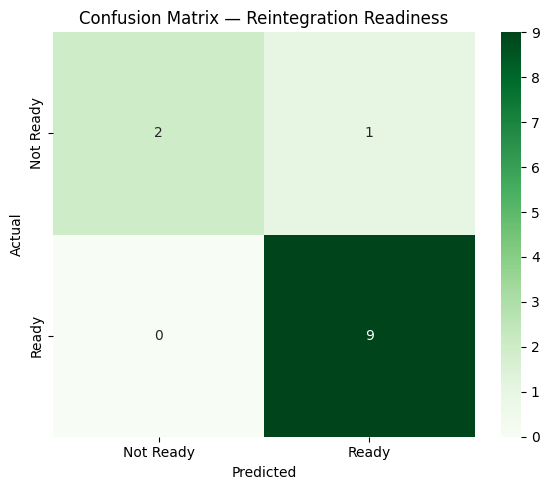

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Ready', 'Ready'],
            yticklabels=['Not Ready', 'Ready'])
plt.title('Confusion Matrix — Reintegration Readiness')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 5: Model Training — Multi-class Status Prediction

In [12]:
# Multi-class classifier
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_multi.fit(X_train, y_train_m)
y_pred_m = rf_multi.predict(X_test)

# Handle classes present in test set only
present_labels = sorted(unique_labels(y_test_m, y_pred_m))
label_names = {0: 'Not Started', 1: 'On Hold', 2: 'In Progress', 3: 'Completed'}
target_names_present = [label_names[l] for l in present_labels]

print('=== MULTI-CLASS REINTEGRATION STATUS PREDICTION ===')
print(classification_report(y_test_m, y_pred_m,
                            labels=present_labels,
                            target_names=target_names_present))

=== MULTI-CLASS REINTEGRATION STATUS PREDICTION ===
              precision    recall  f1-score   support

 Not Started       0.00      0.00      0.00         2
     On Hold       1.00      1.00      1.00         1
 In Progress       0.40      0.33      0.36         6
   Completed       0.33      0.67      0.44         3

    accuracy                           0.42        12
   macro avg       0.43      0.50      0.45        12
weighted avg       0.37      0.42      0.38        12



## Section 6: Feature Importance — What Drives Readiness?

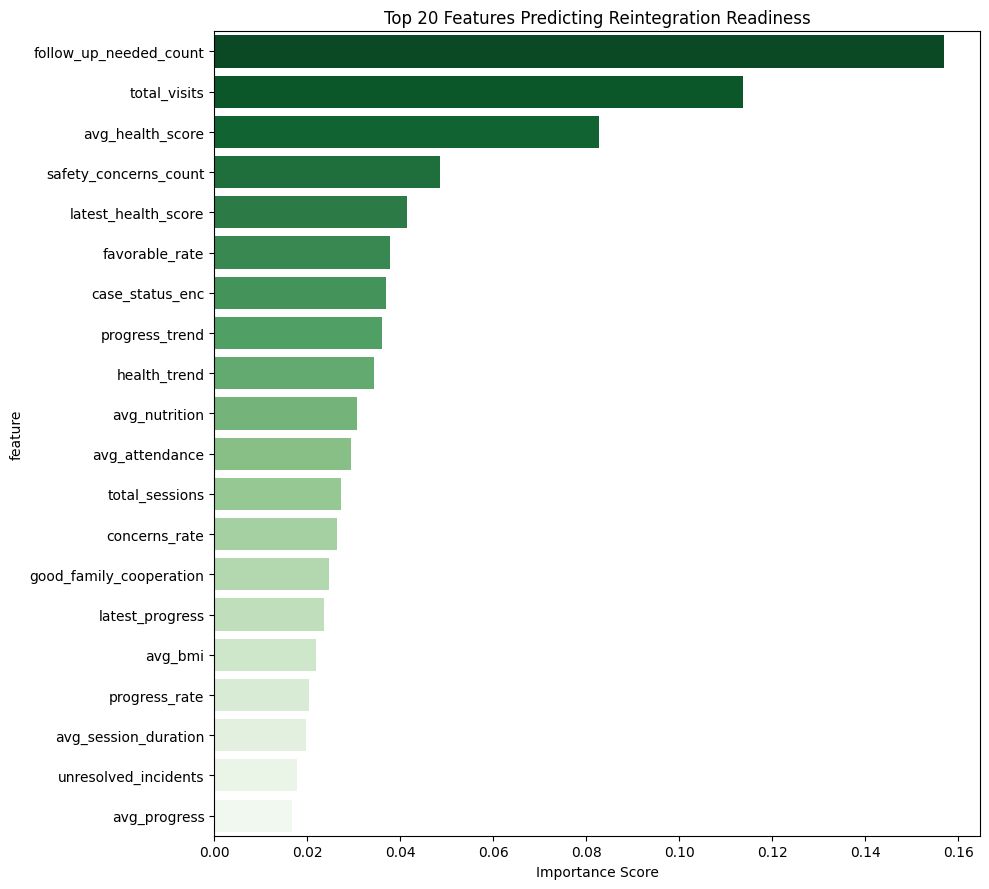

Top 10 readiness predictors:
               feature  importance
follow_up_needed_count    0.156823
          total_visits    0.113622
      avg_health_score    0.082828
 safety_concerns_count    0.048576
   latest_health_score    0.041533
        favorable_rate    0.037893
       case_status_enc    0.037032
        progress_trend    0.036027
          health_trend    0.034369
         avg_nutrition    0.030691


In [13]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_binary.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 9))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Greens_r')
plt.title('Top 20 Features Predicting Reintegration Readiness')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 readiness predictors:')
print(importance_df.head(10).to_string(index=False))

In [14]:
# Cross validation
cv_scores = cross_val_score(rf_binary, X, y_binary, cv=5, scoring='roc_auc')
print(f'Cross-validation AUC-ROC: {cv_scores}')
print(f'Mean AUC-ROC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})')

Cross-validation AUC-ROC: [0.96875 1.      0.96875 0.84375 0.8125 ]
Mean AUC-ROC: 0.919 (+/- 0.151)


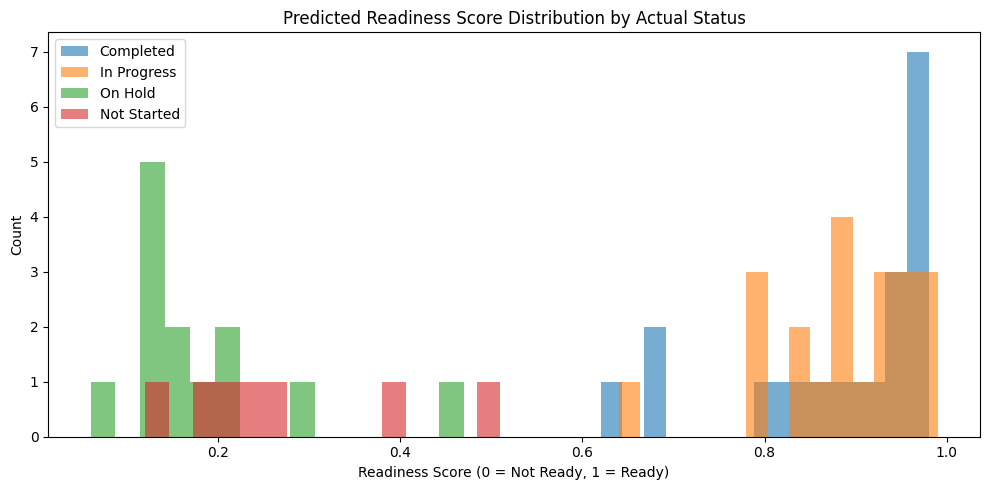

In [15]:
# Readiness score distribution
readiness_probs = rf_binary.predict_proba(X)[:, 1]
df['readiness_score'] = readiness_probs

plt.figure(figsize=(10, 5))
for status in status_order:
    subset = df[df['reintegration_status'] == status]['readiness_score']
    plt.hist(subset, bins=15, alpha=0.6, label=status)
plt.title('Predicted Readiness Score Distribution by Actual Status')
plt.xlabel('Readiness Score (0 = Not Ready, 1 = Ready)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Section 7: Deployment — Score a Resident's Readiness

In [16]:
import pickle

def predict_reintegration_readiness(resident_features: dict) -> dict:
    """
    Predict reintegration readiness for a resident.
    Returns a readiness score, predicted status, and recommended action.
    """
    input_df = pd.DataFrame([resident_features])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_cols].fillna(0)

    readiness_score = rf_binary.predict_proba(input_df)[0][1]
    status_pred = rf_multi.predict(input_df)[0]
    status_label = {0: 'Not Started', 1: 'On Hold', 2: 'In Progress', 3: 'Completed'}[status_pred]

    if readiness_score >= 0.75:
        action = 'READY — initiate reintegration planning and family/guardian contact'
    elif readiness_score >= 0.5:
        action = 'PROGRESSING — schedule case conference to review reintegration timeline'
    elif readiness_score >= 0.25:
        action = 'IN DEVELOPMENT — continue current care plan, reassess in 30 days'
    else:
        action = 'NOT READY — focus on stabilization before reintegration planning'

    return {
        'readiness_score': round(readiness_score, 3),
        'predicted_status': status_label,
        'recommended_action': action
    }

# Example prediction
example_resident = {
    'current_risk_level_enc': 1,
    'initial_risk_level_enc': 2,
    'case_category_enc': 1,
    'case_status_enc': 0,
    'reintegration_type_enc': 2,
    'referral_source_enc': 1,
    'has_special_needs': 0,
    'is_pwd': 0,
    'family_solo_parent': 0,
    'family_is_4ps': 1,
    'family_informal_settler': 0,
    'family_indigenous': 0,
    'sub_cat_trafficked': 0,
    'sub_cat_physical_abuse': 1,
    'sub_cat_sexual_abuse': 0,
    'sub_cat_at_risk': 0,
    'avg_health_score': 3.8,
    'latest_health_score': 4.0,
    'health_trend': 0.5,
    'avg_nutrition': 3.5,
    'avg_sleep': 3.7,
    'avg_energy': 3.6,
    'avg_bmi': 20.5,
    'medical_checkup_rate': 0.9,
    'psychological_checkup_rate': 0.85,
    'health_records_count': 12,
    'avg_attendance': 0.88,
    'latest_progress': 72.0,
    'avg_progress': 65.0,
    'progress_trend': 15.0,
    'education_records_count': 12,
    'total_plans': 4,
    'completed_plans': 3,
    'in_progress_plans': 1,
    'on_hold_plans': 0,
    'plan_completion_rate': 0.75,
    'total_visits': 6,
    'favorable_rate': 0.83,
    'safety_concerns_count': 0,
    'follow_up_needed_count': 1,
    'good_family_cooperation': 0.8,
    'total_sessions': 15,
    'progress_rate': 0.73,
    'concerns_rate': 0.2,
    'avg_session_duration': 58,
    'total_incidents': 1,
    'unresolved_incidents': 0,
    'high_severity_incidents': 0
}

result = predict_reintegration_readiness(example_resident)
print('=== REINTEGRATION READINESS PREDICTION ===')
for key, value in result.items():
    print(f'{key}: {value}')

# Save model
with open('reintegration_readiness_model.pkl', 'wb') as f:
    pickle.dump({
        'binary_classifier': rf_binary,
        'multi_classifier': rf_multi,
        'feature_cols': feature_cols,
        'status_mapping': status_mapping
    }, f)

print('\nModel saved to reintegration_readiness_model.pkl')

=== REINTEGRATION READINESS PREDICTION ===
readiness_score: 0.42
predicted_status: On Hold
recommended_action: IN DEVELOPMENT — continue current care plan, reassess in 30 days

Model saved to reintegration_readiness_model.pkl


## Section 8: Summary

### What This Pipeline Does
Predicts each resident's reintegration readiness using a comprehensive set of features spanning health, education, counseling, home visitation, intervention plans, and incident history. Outputs both a readiness score (0–1) and a predicted status (Not Started / On Hold / In Progress / Completed).

### Key Findings
- Plan completion rate and favorable home visitation outcomes are among the strongest predictors of reintegration readiness
- Health trend (improving vs declining scores) matters more than absolute health score levels
- Education progress trend is a stronger predictor than raw attendance rate
- Unresolved incidents significantly reduce readiness probability
- Good family cooperation during home visits is a strong positive predictor
- Current risk level is more predictive than initial risk level — improvement matters

### Deployment in Web App
The model is integrated into each resident's profile page in the HavenBridge admin portal. A readiness score gauge (0–100%) updates automatically when new health, education, or visitation records are added. Caseworkers receive an automated alert when a resident's readiness score crosses the 75% threshold, prompting a case conference to begin reintegration planning.

### Limitations
- Small dataset (60 residents) limits model generalizability — predictions will improve significantly as HavenBridge builds its own resident history
- Reintegration status labels reflect point-in-time assessments and may not capture dynamic changes
- Model should always be used as a decision support tool, not a replacement for qualified social worker judgment
- Cultural factors affecting family reintegration are not fully captured in the structured data